# Projet Machine Learning : Prédiction de la météo

Imports de certains package nécessaire

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import naive_bayes,svm
from sklearn.svm import SVC
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

Import des données et remplacement des target vide par soleil

*Question* : Est ce que toutes les valeurs manquantes sont des soleils ?

In [3]:
df = pd.read_csv('data/madrid_meteo_data.csv')

df.loc[df[' Events'].isnull(), ' Events'] = 'Sun' 



*CHOIX 1* : Supprimer les lignes avec des valeurs manquantes (sauf pour Max Gust SpeedKm/h)

Et supprimer les lignes avec des y trop rares (moins de 10 occurrences)

In [ ]:
#colonnes qui me paraissent inutiles pour la prédiction de l'événement météo
X = df.drop(columns=['CET', 'WindDirDegrees'], axis=1)

# Pour les rafales de vent, on remplace les valeurs manquantes par 0 (pas de rafales)
X[' Max Gust SpeedKm/h'] = X[' Max Gust SpeedKm/h'].fillna(0)

X.dropna(inplace=True) 

etiquettes_drop = X[' Events'].value_counts()[X[' Events'].value_counts() < 10].index
X.drop(X[X[' Events'].isin(etiquettes_drop)].index, inplace=True)

Y = X[' Events']
X.drop(columns=[' Events'], inplace=True)    # 5400 lignes gardées sur 6800

print ( 'nombre d occurrences de chaque classe : \n', Y.value_counts(normalize=True)* len(Y), '\n\n')

nombre d occurrences de chaque classe : 
  Events
Sun                  3653.0
Rain                 1140.0
Rain-Thunderstorm     247.0
Fog                   221.0
Fog-Rain               69.0
Thunderstorm           45.0
Rain-Snow              33.0
Snow                   14.0
Name: proportion, dtype: float64 




Premier modèle  : XG boost sans paramètres

In [ ]:
# 70% apprentissage, 30% temporaire
X_app, X_temp, Y_app, Y_temp = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    shuffle=True)

# Diviser les 30% restants en 15% validation et 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True)

# Transformer les étiquettes de classes en entiers
le = LabelEncoder()
Y_app_encoded = le.fit_transform(Y_app)
Y_val_encoded = le.transform(Y_val)
Y_test_encoded = le.transform(Y_test)

# Poids pour chaque classe car les classes sont déséquilibrées
weights = compute_sample_weight(
    class_weight="balanced",
    y=Y_app_encoded)

mod  =xgb.XGBClassifier()
mod.fit(X_app, Y_app_encoded, sample_weight=weights)

Y_pred = mod.predict(X_test)

# Resultats du modèle sur le jeu de test
print(classification_report(
        Y_test_encoded,
        Y_pred,
        target_names=le.classes_))


                   precision    recall  f1-score   support

              Fog       0.55      0.69      0.61        32
         Fog-Rain       0.20      0.14      0.17        14
             Rain       0.61      0.72      0.66       161
        Rain-Snow       0.40      0.33      0.36         6
Rain-Thunderstorm       0.38      0.32      0.35        34
             Snow       0.00      0.00      0.00         2
              Sun       0.91      0.88      0.89       553
     Thunderstorm       0.40      0.17      0.24        12

         accuracy                           0.79       814
        macro avg       0.43      0.41      0.41       814
     weighted avg       0.79      0.79      0.79       814



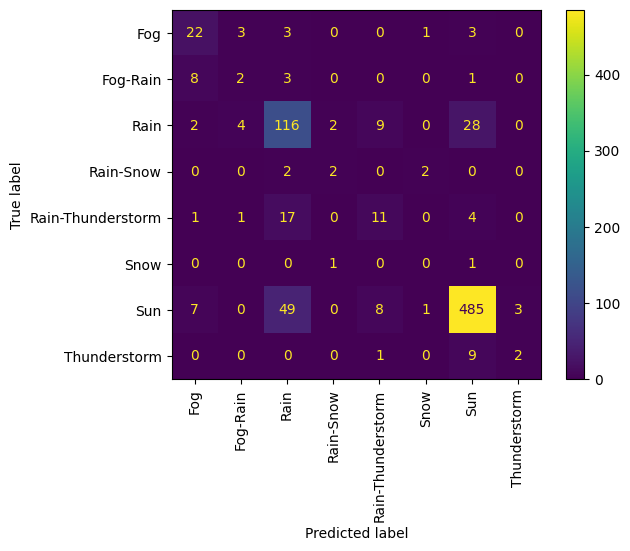

In [8]:
ConfusionMatrixDisplay.from_predictions(
    Y_test_encoded,
    Y_pred,
    display_labels=le.classes_,
    xticks_rotation=90)